In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [16]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from project.models import EDMSerie
from project.util.device import get_available_acc
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE
from tqdm import trange

In [3]:
plt.style.use(['science','no-latex', 'ieee'])

In [4]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [5]:
device = "cuda:1"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [11]:
SIGMA = 0.1

In [20]:
psnrs_01 = []
psnrs_025 = []
psnrs_05 = []
psnrs_075 = []
psnrs_1 = []

psnrs = {
    0.1: [],
    0.25: [],
    0.5: [],
    0.75: [],
    1: [],
}

n = 64
x = torch.zeros((n, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(10_000)[:n]):
    x[i] = data[img].to(device)

x_noisy = {}

w = torch.randn_like(x)

for sigma in psnrs.keys():

    e = sigma * w
    x_noisy[sigma] = x + e

models = {
    0.1: EDMSerie.from_checkpoint(PATH, device, sigma_noise=0.1, N=2).to(device),
    0.25: EDMSerie.from_checkpoint(PATH, device, sigma_noise=0.25, N=2).to(device),
    0.5: EDMSerie.from_checkpoint(PATH, device, sigma_noise=0.5, N=2).to(device),
    0.75: EDMSerie.from_checkpoint(PATH, device, sigma_noise=0.75, N=2).to(device),
    1: EDMSerie.from_checkpoint(PATH, device, sigma_noise=1, N=2).to(device),
}

for N in trange(2, 15):

    for model in models.values():
        model.set_N(N)

    with torch.no_grad():
        for sigma, psnr in psnrs.items():
            x_denoised = models[sigma].denoise(x_noisy[sigma])
            psnr.append(PSNR(x.to("cpu"), x_denoised.to("cpu"), torch.tensor(2)))

100%|██████████| 13/13 [06:34<00:00, 30.38s/it]


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


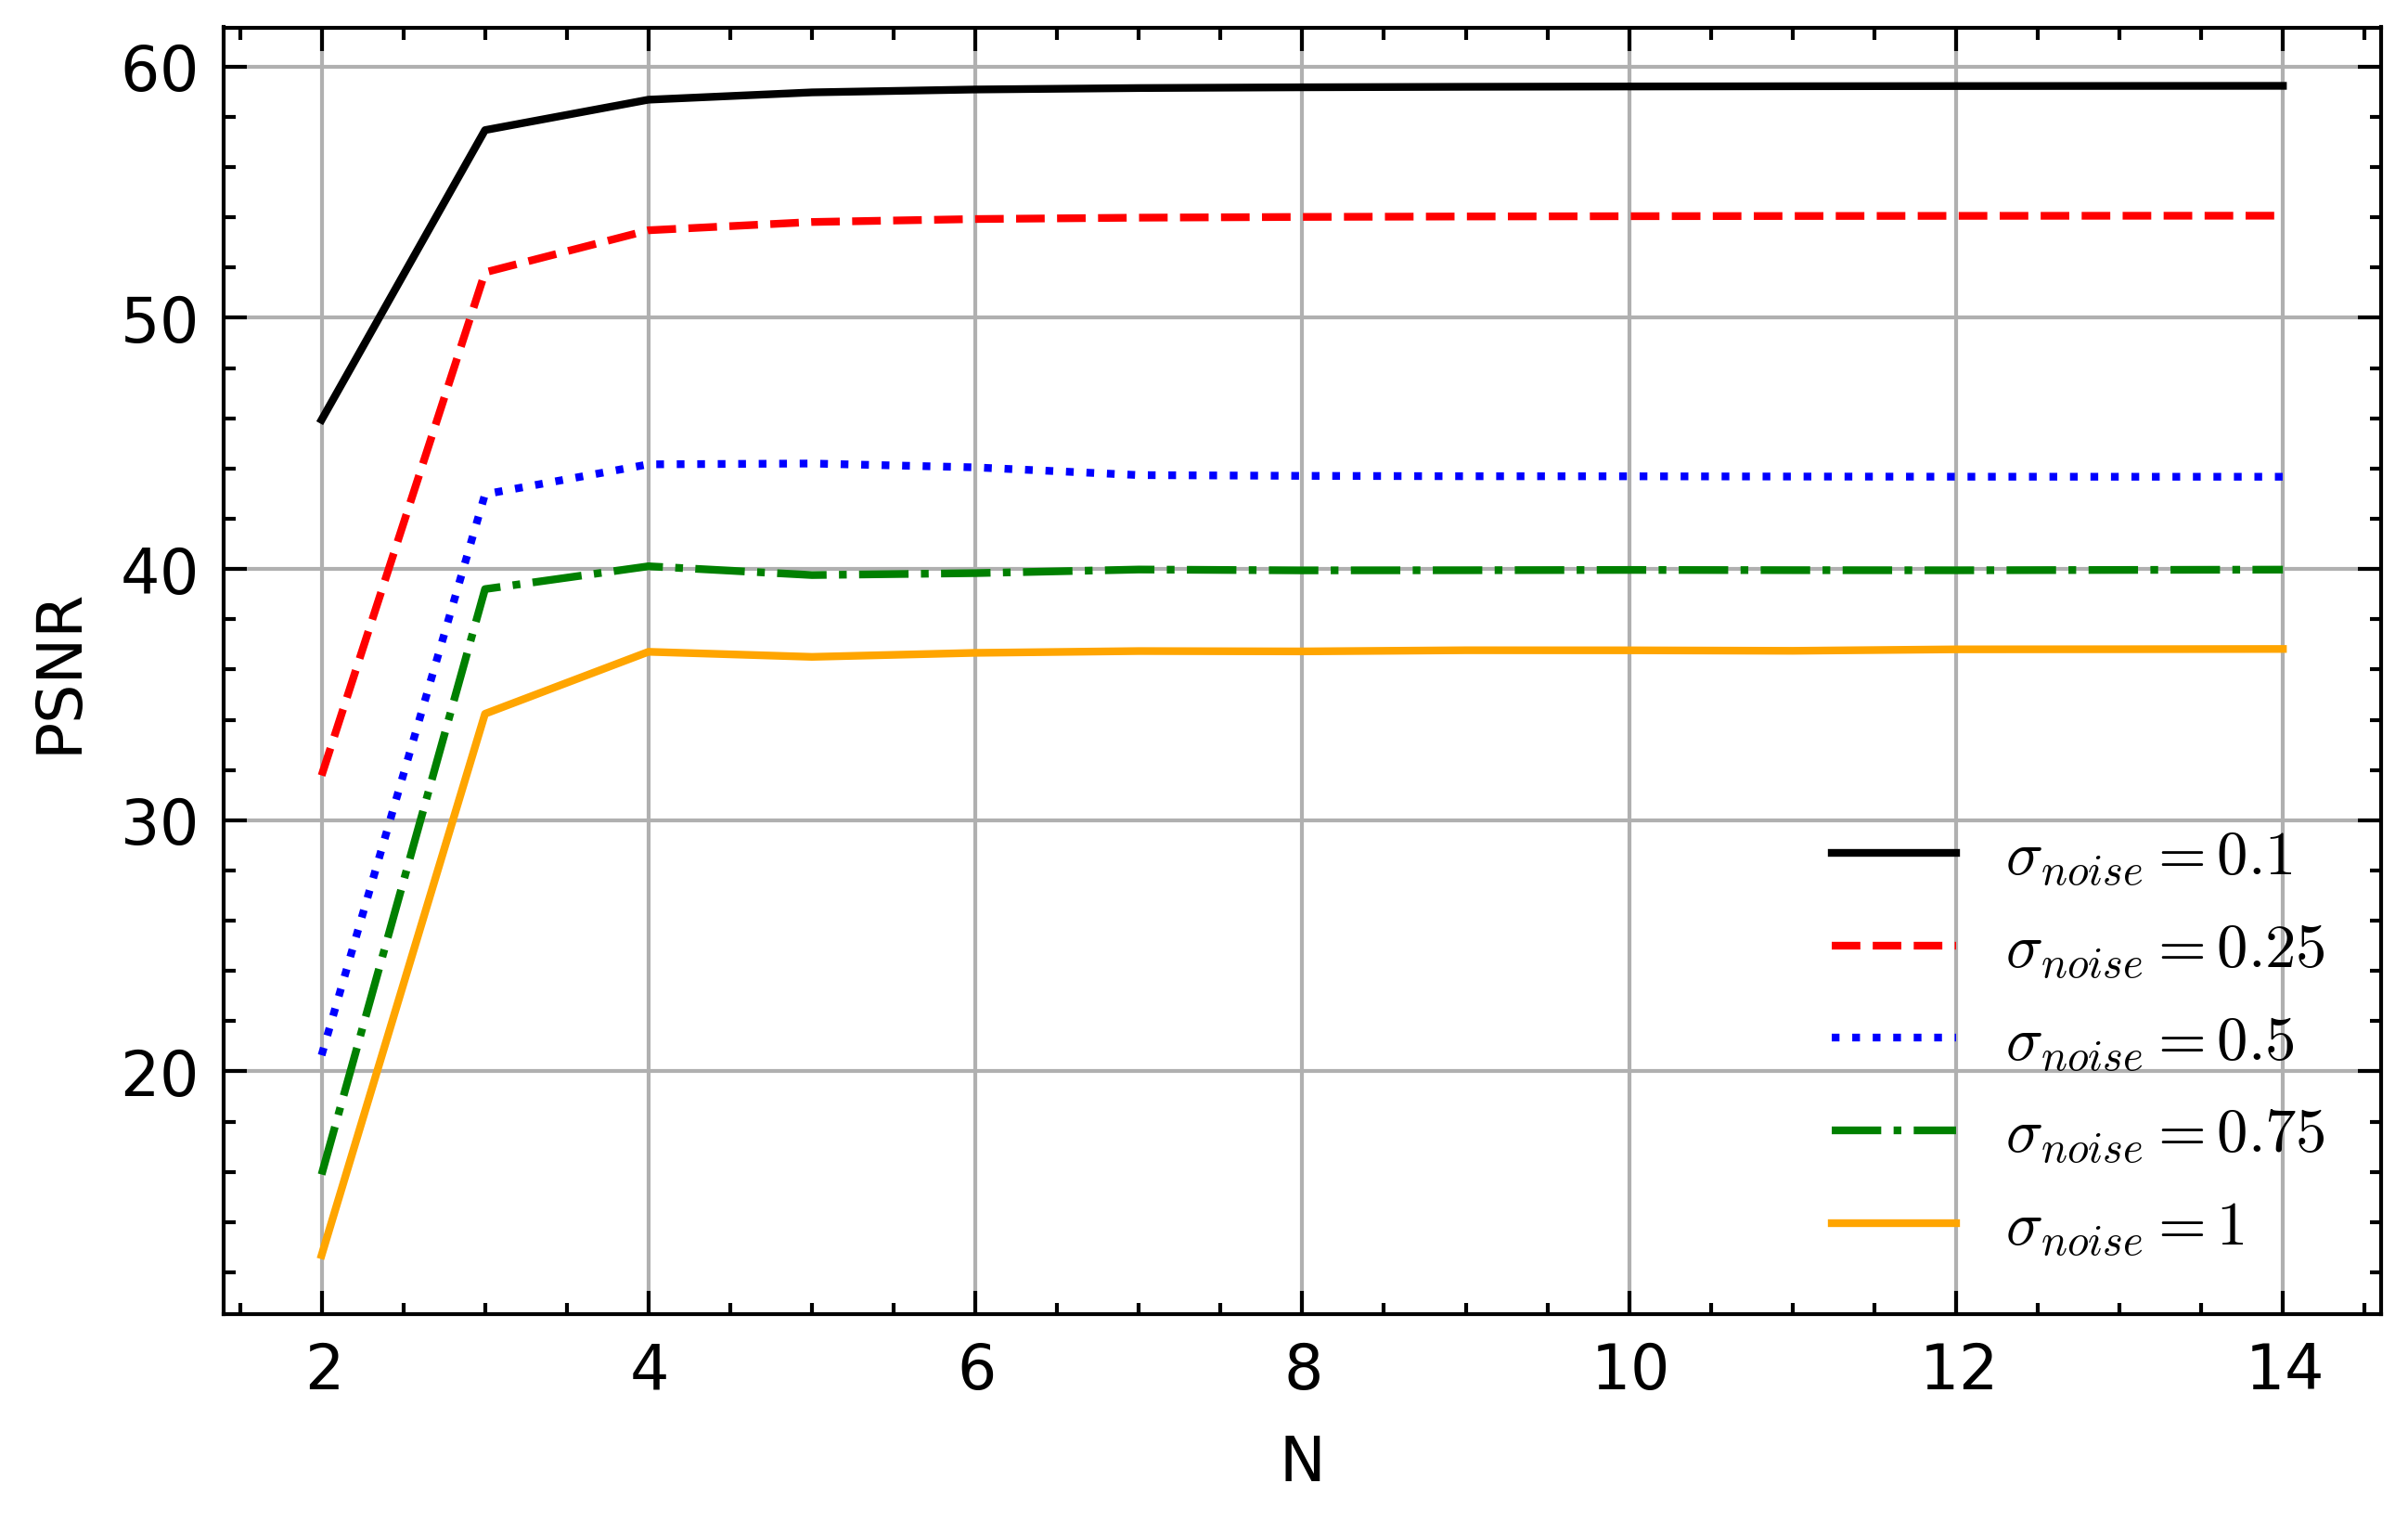

In [31]:
Ns = torch.arange(2, 15)

plt.figure(figsize=(5, 3))

for sigma, psnr in list(psnrs.items())[:-1]:
    plt.plot(Ns, psnr, label="$\\sigma_{noise} = " + str(sigma) + "$")

plt.plot(Ns, psnrs[1], label="$\\sigma_{noise} = " + str(1) + "$", color="orange")

plt.xlabel("N")
plt.ylabel("PSNR")

plt.grid()
plt.legend()

plt.savefig("../results/hyperparameters/N.svg")
plt.show()